# PCA in Scikit-Learn

In [ ]:
import numpy as np

x1 = np.linspace(-10, 10, 100)
# A linear relationship, plus a little noise
x2 = np.array([xi*2 + np.random.normal(loc=0, scale=0.5) for xi in x1]) 

X = np.matrix(list(zip(x1, x2)))

Let's also generate a quick plot of this simple dataset to further orient ourselves:

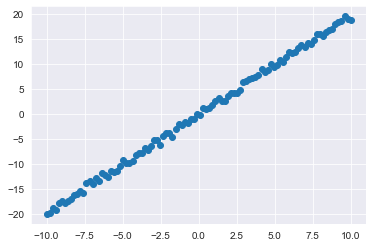

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('darkgrid')

plt.scatter(x1, x2);

## PCA with scikit-learn

Now onto PCA. First, take a look at how simple it is to implement PCA with scikit-learn:

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
transformed = pca.fit_transform(X)

And you can once again plot the updated dataset:

In [ ]:
print(transformed[1])

[22.05854812  0.1355043 ]


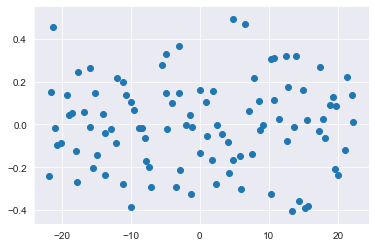

In [ ]:
plt.scatter(transformed[:,0], transformed[:,1]);

In [ ]:
pca.components_

array([[-0.44966748, -0.89319604],
       [ 0.89319604, -0.44966748]])

In [ ]:
pca.mean_

array([ 7.10542736e-17, -5.65368669e-02])

## Interpret Results

Let's take a look at what went on here. PCA transforms the dataset along principal axes. The first of these axes is designed to capture the maximum variance within the data. From here, additional axes are constructed which are orthogonal to the previous axes and continue to account for as much of the remaining variance as possible.

For the current 2-d case, the axes which the data were projected onto look like this:

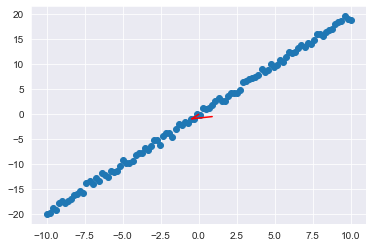

In [ ]:
plt.scatter(x1, x2);
ax1, ay1 = pca.mean_[0], pca.mean_[1]
ax2, ay2 = pca.mean_[0] + pca.components_[0][0], pca.mean_[1] + pca.components_[0][1]
ax3, ay3 = pca.mean_[0] + pca.components_[1][0], pca.mean_[1] + pca.components_[1][1]
plt.plot([ax1, ax2], [ay1, ay2], color='red')
plt.plot([ax2, ax3], [ay2, ay3], color='red');

So, the updated graph you saw is the same dataset rotated onto these red axes:

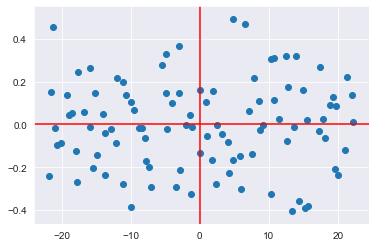

In [ ]:
plt.scatter(transformed[:,0], transformed[:,1])
plt.axhline(color='red')
plt.axvline(color='red');

Note the small scale of the y-axis. You can also plot the transformed dataset on the new axes with a scale similar to what you saw before:

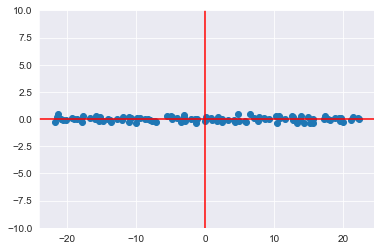

In [ ]:
plt.scatter(transformed[:,0], transformed[:,1])
plt.axhline(color='red')
plt.axvline(color='red')
plt.ylim(-10,10);

Again, this is the geographical interpretation of what just happened:  

<img src="assets/pca_in_scikitlearn/inhouse_pca.png">

## Determine the Explained Variance

Typically, one would use PCA to actually reduce the number of dimensions. In this case, you've simply re-re-parametrized the dataset along new axes. That said, if you look at the first of these primary axes, you can see the patterns encapsulated by the principal component. Moreover, scikit-learn also lets you quickly determine the overall variance in the dataset accounted for in each of the principal components.

In [ ]:
pca.explained_variance_ratio_

array([9.99750028e-01, 2.49972317e-04])

Keep in mind that these quantities are cumulative: principal component 2 attempts to account for the variance not accounted for in the primary component. You can view the total variance using `np.cumsum()`:

In [ ]:
np.cumsum(pca.explained_variance_ratio_)

array([0.99975003, 1.        ])

## Visualize the Principal Component

To help demonstrate the structure captured by the first principal component, observe the impact of coloring the dataset and then visualizing the first component.

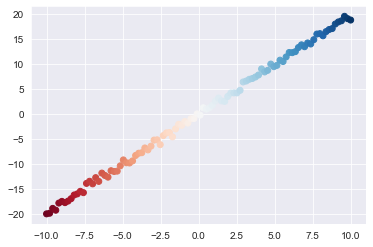

In [ ]:
plt.scatter(x1,x2, c=sns.color_palette('RdBu', n_colors=100));

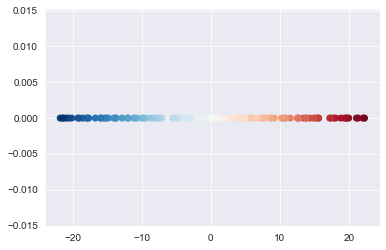

In [ ]:
plt.scatter(transformed[:,0], [0 for i in range(100)] , c=sns.color_palette('RdBu', n_colors=100));

## Steps for Performing PCA

The theory behind PCA rests upon many foundational concepts of linear algebra. After all, PCA is re-encoding a dataset into an alternative basis (the axes). Here are the exact steps:

1. Recenter each feature of the dataset by subtracting that feature's mean from the feature vector
2. Calculate the covariance matrix for your centered dataset
3. Calculate the eigenvectors of the covariance matrix
    1. You'll further investigate the concept of eigenvectors in the upcoming lesson
4. Project the dataset into the new feature space: Multiply the eigenvectors by the mean-centered features

You can see some of these intermediate steps from the `pca` instance object itself.

In [ ]:
# Pulling up the original feature means which were used to center the data
pca.mean_ 

array([7.10542736e-17, 2.61587597e-02])

In [ ]:
# Pulling up the covariance matrix of the mean centered data
pca.get_covariance() 

array([[ 34.35023637,  68.62012556],
       [ 68.62012556, 137.32181974]])

In [ ]:
# Pulling up the eigenvectors of the covariance matrix
pca.components_ 

array([[ 0.44712728,  0.89447035],
       [-0.89447035,  0.44712728]])

---

## Iris dataset

To practice PCA, you'll take a look at the iris dataset. Run the cell below to load it.

In [ ]:
from sklearn import datasets
import pandas as pd
 
iris = datasets.load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['Target'] = iris.get('target')
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Before performing PCA and visualizing the principal components, it's helpful to get a little more context regarding the data that you'll be working with. Run the cell below in order to visualize the pairwise feature plots. With this, notice how the target labels are easily separable by any one of the given features.

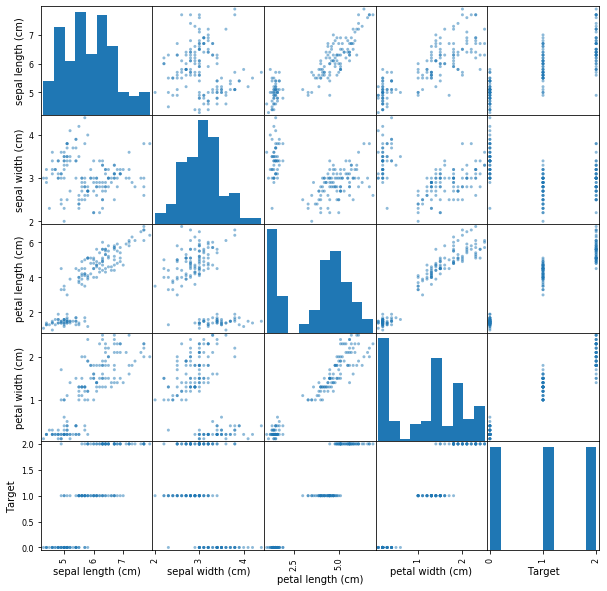

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

pd.plotting.scatter_matrix(df, figsize=(10,10));

- Assign all columns in the following `features` list to `X` 
- Assign the `'Target'` column to `y`

In [ ]:
# Create features and target datasets
features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
X = df[features].values
y = df['Target'].values

Standardize all the columns in `X` using `StandardScaler`.

In [ ]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Standardize the features
X = StandardScaler().fit_transform(X)

# Preview X
pd.DataFrame(data=X, columns=features).head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


## PCA Projection to 2-D Space

Now its time to perform PCA! Project the original data which is 4 dimensional into 2 dimensions. The new components are just the two main dimensions of variance present in the data.

- Initialize an instance of PCA from scikit-learn with two components
- Fit the data to the model
- Extract the first two principal components from the trained model

In [ ]:
# Import PCA
from sklearn.decomposition import PCA

# Instantiate PCA
pca = PCA(n_components=2)

# Fit PCA
principalComponents = pca.fit_transform(X)

To visualize the components, it will be useful to also look at the target associated with the particular observation. 
As such, append the target (flower type) to the principal components in a pandas dataframe.

In [ ]:
# Create a new dataset from principal components 
df = pd.DataFrame(data = principalComponents, 
                  columns = ['PC1', 'PC2'])

target = pd.Series(iris['target'], name='target')

result_df = pd.concat([df, target], axis=1)
result_df.head(5)

,PC1,PC2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


In [ ]:
result_df.sample(5)

,PC1,PC2,target
82,0.241538,-0.777256,1
56,0.746530,0.773019,1
147,1.521170,0.269069,2
110,1.364175,0.692756,2
129,1.863648,0.562291,2


Great, you now have a set of two dimensions, reduced from four against our target variable, the flower type.

## Visualize Principal Components

Using the target data, we can visualize the principal components according to the class distribution. 
- Create a scatter plot from principal components while color coding the examples according to what flower type each example is classified as

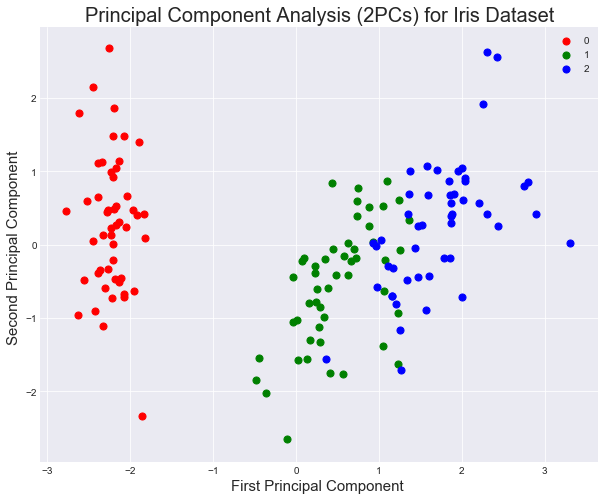

In [ ]:
# Principal Componets scatter plot
plt.style.use('seaborn-dark')
fig = plt.figure(figsize = (10,8))
ax = fig.add_subplot(1,1,1) 
ax.set_xlabel('First Principal Component ', fontsize = 15)
ax.set_ylabel('Second Principal Component ', fontsize = 15)
ax.set_title('Principal Component Analysis (2PCs) for Iris Dataset', fontsize = 20)

targets = [0, 1, 2]
colors = ['r', 'g', 'b']
for target, color in zip(targets, colors):
    indicesToKeep = iris['target'] == target
    ax.scatter(result_df.loc[indicesToKeep, 'PC1'], 
               result_df.loc[indicesToKeep, 'PC2'], 
               c = color, 
               s = 50)
ax.legend(targets)
ax.grid()

## Explained Variance


You can see above that the three classes in the dataset are fairly well separable. As such, this compressed representation of the data is probably sufficient for the classification task at hand. Compare the variance in the overall dataset to what was captured from your two primary components.

In [ ]:
# Calculate the variance explained by pricipal components
print('Variance of each component:', pca.explained_variance_ratio_)
print('\n Total Variance Explained:', round(sum(list(pca.explained_variance_ratio_))*100, 2))

Variance of each component: [0.72962445 0.22850762]

 Total Variance Explained: 95.81


As you should see, these first two principal components account for the vast majority of the overall variance in the dataset. This is indicative of the total information encapsulated in the compressed representation compared to the original encoding.

## Compare Performance of a Classifier with PCA

Since the principal components explain 95% of the variance in the data, it is interesting to consider how a classifier trained on the compressed version would compare to one trained on the original dataset.

- Run a `KNeighborsClassifier` to classify the Iris dataset 
- Use a train/test split of 80/20
- For the reproducibility of results, set `random_state=9` for the split
- Time the process for splitting, training and making predictions

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import time

X = iris.data
y = iris.target
start = time.time()
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=9)
model = KNeighborsClassifier()
model.fit(X_train, Y_train)
Yhat = model.predict(X_test)
acc = metrics.accuracy_score(Yhat, Y_test)
end = time.time()
print('Accuracy:', acc)
print ('Time Taken:', end - start)

Accuracy: 1.0
Time Taken: 0.00498199462890625


Great, so you can see that we are able to classify the data with 100% accuracy in the given time. Remember the time taken may be different based on the load on your CPU and number of processes running on your machine. 

Now repeat the above process for the dataset made from principal components: 

- Run a `KNeighborsClassifier` to classify the Iris dataset with principal components
- Use a train/test split of 80/20
- For the reproducibility of results, set `random_state=9` for the split
- Time the process for splitting, training and making predictions

In [ ]:
X = result_df[['PC1', 'PC2']]
y = result_df['target']

start = time.time()
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=9)
model = KNeighborsClassifier()
model.fit(X_train, Y_train)
Yhat = model.predict(X_test)
acc = metrics.accuracy_score(Yhat, Y_test)
end = time.time()
print('Accuracy:', acc)
print ('Time Taken:', end - start)

Accuracy: 0.9666666666666667
Time Taken: 0.0059545040130615234


Although some accuracy is lost in this representation of the data, we were able to use half of the number of features to train the model!

In more complex cases, PCA can even improve the accuracy of some machine learning tasks. In particular, PCA can be useful to reduce overfitting.

## Visualize the Learned Decision Boundary 

Run the cell below to visualize the decision boundary learned by the k-nearest neighbor classification model trained using the principal components of the data.

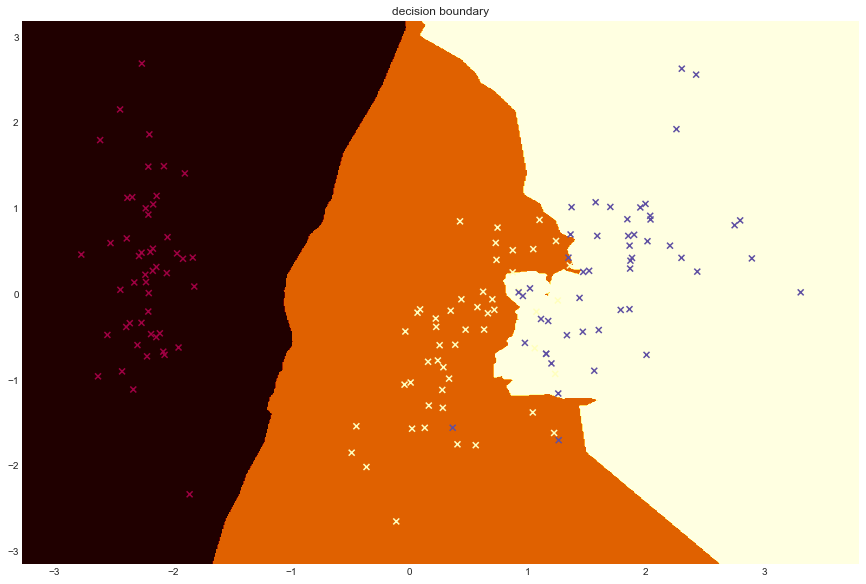

In [ ]:
# Plot decision boundary using principal components 
import numpy as np 
def decision_boundary(pred_func):
    
    # Set the boundary
    x_min, x_max = X.iloc[:, 0].min() - 0.5, X.iloc[:, 0].max() + 0.5
    y_min, y_max = X.iloc[:, 1].min() - 0.5, X.iloc[:, 1].max() + 0.5
    h = 0.01
    
    # Build meshgrid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = pred_func(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the contour
    plt.figure(figsize=(15,10))
    plt.contourf(xx, yy, Z, cmap=plt.cm.afmhot)
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, cmap=plt.cm.Spectral, marker='x')

decision_boundary(lambda x: model.predict(x))

plt.title('decision boundary');